In [2]:
import os
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [14]:
files = glob.glob('./dataview/*.xlsx')
files = [file for file in files if 'CoT' not in file]

dfs = list()
for file in files:
    dfs.append(pd.read_excel(file, sheet_name='ModelFamily'))

df = pd.concat(dfs, axis=0, ignore_index=True).groupby('ModelFamily')['max'].mean()
df = df.rename({
    '01-ai':'01-AI', 
    'baichuan-inc': 'Baichuan-Inc', 
    'deepseek': 'DeepSeek', 
    'internlm':'InternLM', 
    'meta-llama': 'LLaMA', 
    'microsoft': 'MicroSoft',
    'mistralai': 'Mistral-AI',
    'openai': 'OpenAI'})
df_sorted = df.sort_values(ascending=False)
df_sorted

ModelFamily
DeepSeek        64.365222
Qwen            63.028628
OpenAI          61.084324
LLaMA           60.375283
01-AI           48.580441
THUDM           48.127940
MicroSoft       44.147503
Mistral-AI      43.900651
InternLM        39.163580
Baichuan-Inc     1.778397
Name: max, dtype: float64

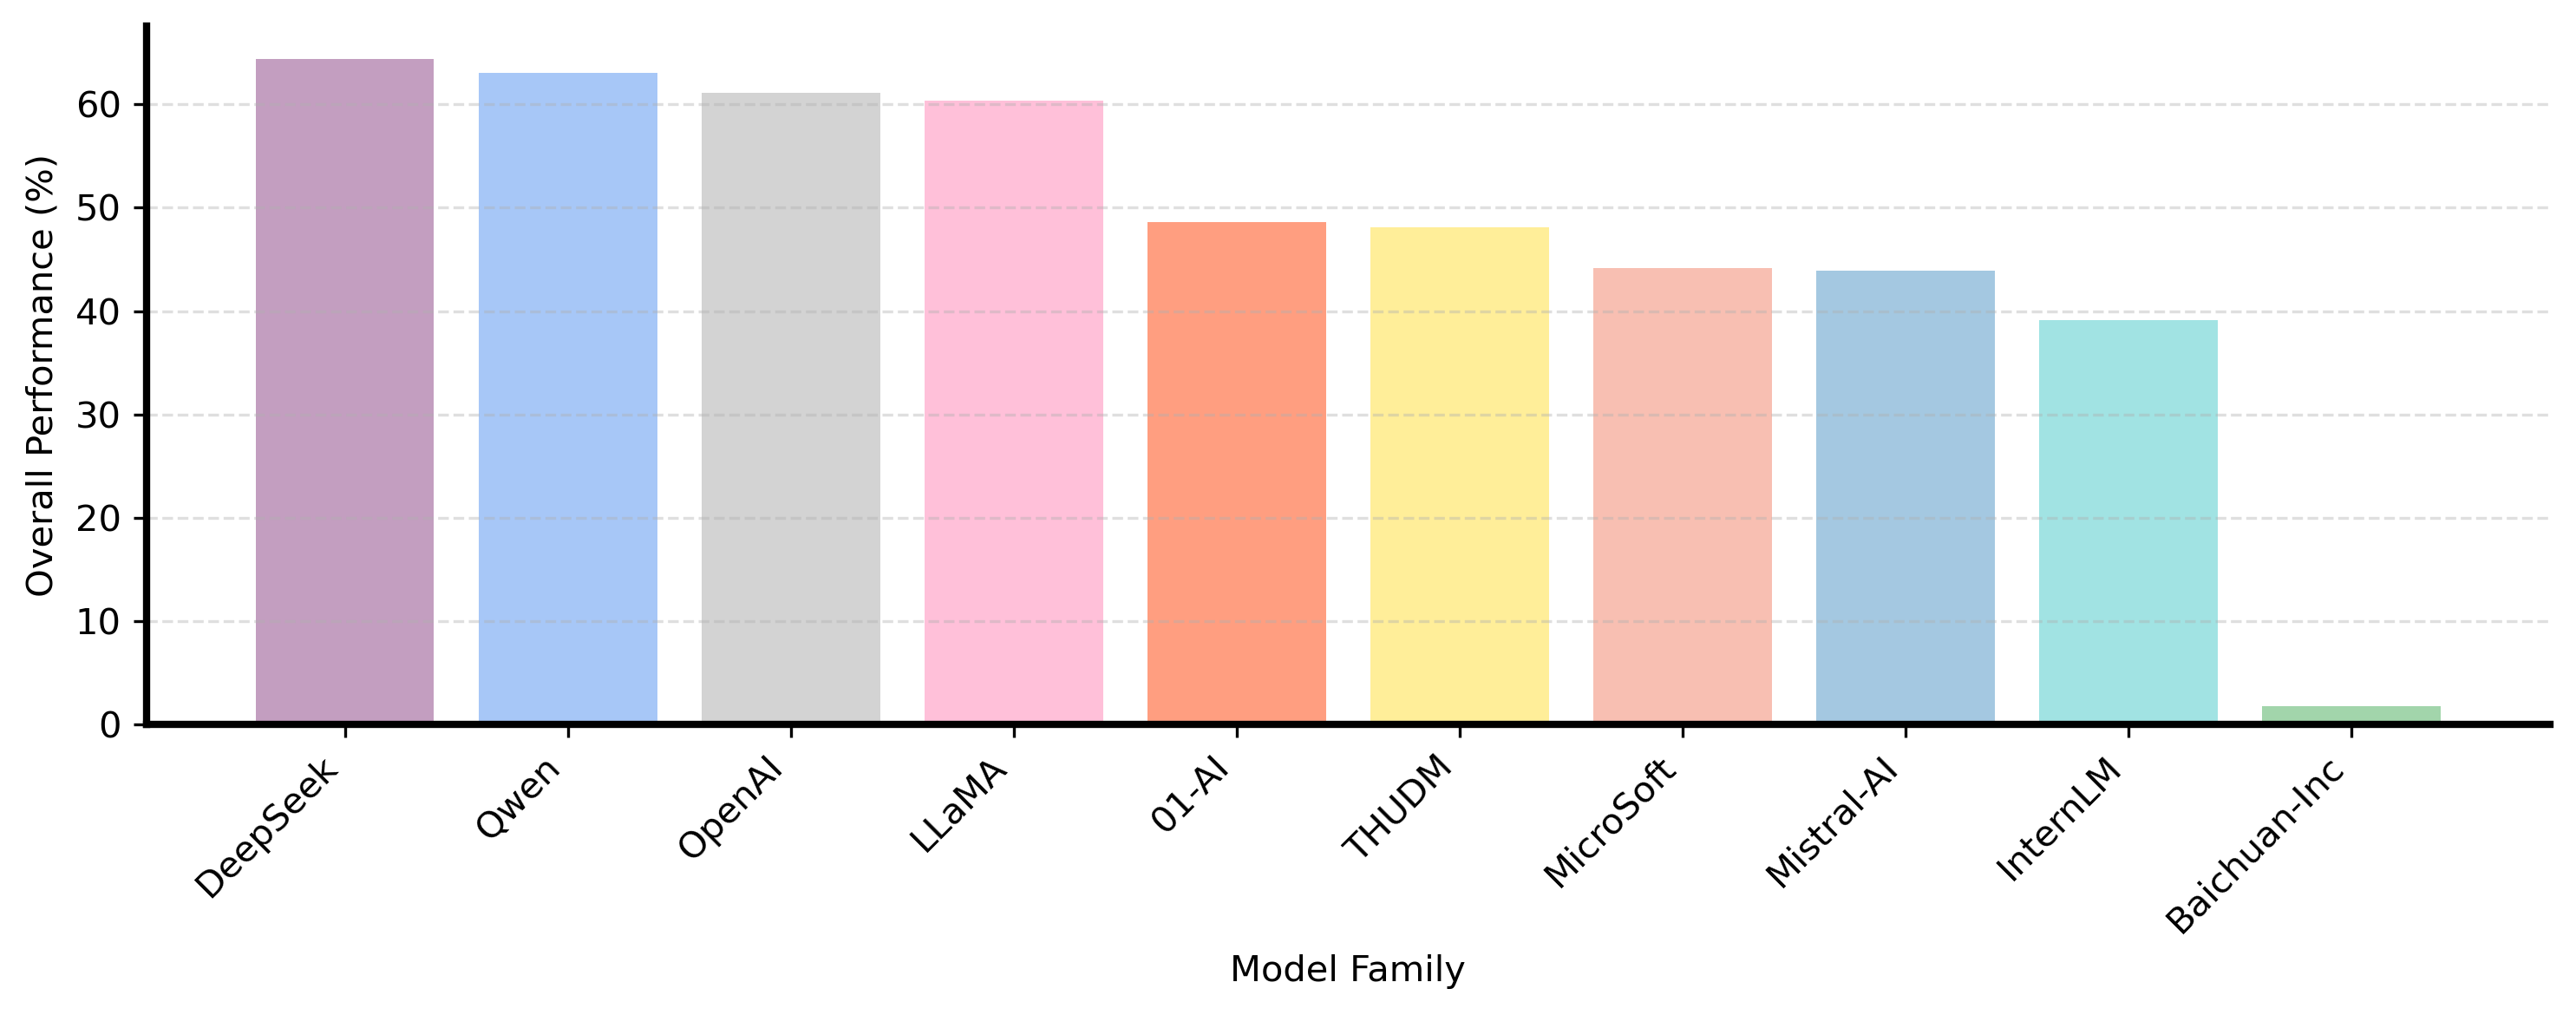

In [27]:
colors = {
    '01-AI': '#FF9E80',
    'Qwen': '#A7C7F7',
    'THUDM': '#FFEE99',
    'Baichuan-Inc': '#A2D5AB',
    'DeepSeek': '#C39EC0',
    'InternLM': '#A1E3E3',
    'LLaMA': '#FFC0D9',
    'MicroSoft': '#F8BFB2',
    'Mistral-AI': '#A4C8E1',
    'OpenAI': '#D3D3D3'
}

bar_colors = [colors[org] for org in df_sorted.index]

plt.figure(figsize=(10, 4), dpi=300)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.bar(df_sorted.index, df_sorted.values, color=bar_colors)
plt.xlabel('Model Family')
plt.ylabel('Overall Performance (%)')
plt.xticks(fontsize=10, rotation=45, ha='right')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)


plt.tight_layout()
plt.show()